In [1]:
import sys
import os
# Add project root to path so we can import eval_utils
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
from pathlib import Path
from eval_utils import (
    read_jsonl_file, 
    extract_evaluation_data, 
    align_evaluation_data,
    specificity_multiclass, 
    plot_confusion_matrix,
    recall_at_k,
    diversity_at_k,
    grounded_and_unsupported_counts,
    evidence_citation_rate,
    contradiction_flags,
    DEFAULT_LEXICON
)
from sklearn.metrics import accuracy_score, classification_report, cohen_kappa_score

# 1. Load results
raw_df = pd.read_json("../results/final-gpt.jsonl", lines=True)

# 2. Extract structured evaluation data
df_ini_raw = extract_evaluation_data(raw_df, target_agent="diagnose")
df_final_raw = extract_evaluation_data(raw_df, target_agent="synthesizer")

# 3. Align data (only keep rows where BOTH diagnoses exist)
df_aligned = align_evaluation_data(df_ini_raw, df_final_raw)
df_aligned.dropna(subset=["diagnosis_ini", "diagnosis_final"], inplace=True)

print(f"Loaded and aligned {len(df_aligned)} cases for evaluation.")
df_aligned.head(5)

Loaded and aligned 300 cases for evaluation.


,image_path,diagnosis_ini,ground_truth,diagnosis_final,reasoning,confidence,differential,retrieved_cases
0,ISIC_0028652,Basal cell carcinoma,Basal cell carcinoma,Basal cell carcinoma,Both the initial assessment and the critique r...,Medium,Actinic keratosis (possible progression to squ...,"[{'image_path': 'ISIC_0032132', 'age': 60, 'se..."
1,ISIC_0029680,Actinic Keratosis,Basal cell carcinoma,Actinic Keratosis,Both the initial assessment and the critique c...,Medium,Squamous cell carcinoma,"[{'image_path': 'ISIC_0035308', 'age': 65, 'se..."
2,ISIC_0024411,Pigmented benign keratosis,Basal cell carcinoma,Basal cell carcinoma,Both the initial proposal (pigmented benign ke...,Medium,Pigmented benign keratosis,"[{'image_path': 'ISIC_0025753', 'age': 70, 'se..."
3,ISIC_0028283,Basal cell carcinoma,Basal cell carcinoma,Basal cell carcinoma,Both arguments have merit. The original assess...,Medium,Squamous cell carcinoma,"[{'image_path': 'ISIC_0027175', 'age': 70, 'se..."
4,ISIC_0032414,Pigmented benign keratosis,Basal cell carcinoma,Pigmented benign keratosis,Both arguments are plausible. Strengths suppor...,Medium,Basal cell carcinoma,"[{'image_path': 'ISIC_0027905', 'age': 70, 'se..."


In [2]:
y_true = df_aligned["ground_truth"]
y_ini_pred = df_aligned["diagnosis_ini"]
y_final_pred = df_aligned["diagnosis_final"]

# --- Initial Predictions ---
ini_acc = accuracy_score(y_true, y_ini_pred)
ini_spec = specificity_multiclass(y_true, y_ini_pred)

# --- Final Predictions ---
fin_acc = accuracy_score(y_true, y_final_pred)
fin_spec = specificity_multiclass(y_true, y_final_pred)
kappa = cohen_kappa_score(y_true, y_final_pred)

# --- Pipeline Metrics ---
recall_k = recall_at_k(y_true.tolist(), df_aligned["retrieved_cases"].tolist())
diversity_k = diversity_at_k(df_aligned["retrieved_cases"].tolist())

# Disagreement rate
disagreement_rate = np.mean([1.0 if ini != fin else 0.0 for ini, fin in zip(y_ini_pred, y_final_pred)])

# Corrected errors (Initial wrong -> Final correct)
init_wrong_mask = (y_ini_pred != y_true)
if init_wrong_mask.any():
    corrected = sum((y_ini_pred != y_true) & (y_final_pred == y_true))
    corr_err_rate = corrected / init_wrong_mask.sum()
else:
    corr_err_rate = 0.0

print("### Initial Predictions ###")
print(f"✅ Accuracy: {ini_acc:.4f}")
print(f"📊 Macro Specificity: {ini_spec['macro_avg']:.4f}")
print("\n### Final Predictions ###")
print(f"✅ Accuracy: {fin_acc:.4f}")
print(f"📊 Macro Specificity: {fin_spec['macro_avg']:.4f}")
print(f"✅ Cohen's Kappa: {kappa:.4f}")
print(f"✅ Recall@K: {recall_k:.4f}")
print(f"✅ Diversity@K: {diversity_k:.4f}")
print(f"✅ Corrected-Error Rate: {corr_err_rate:.4f}")
print(f"✅ Disagreement Rate: {disagreement_rate:.4f}")

### Initial Predictions ###
✅ Accuracy: 0.6667
📊 Macro Specificity: 0.9450

### Final Predictions ###
✅ Accuracy: 0.8567
📊 Macro Specificity: 0.9763
✅ Cohen's Kappa: 0.8101
✅ Recall@K: 0.9567
✅ Diversity@K: 0.7611
✅ Corrected-Error Rate: 0.7000
✅ Disagreement Rate: 0.3033


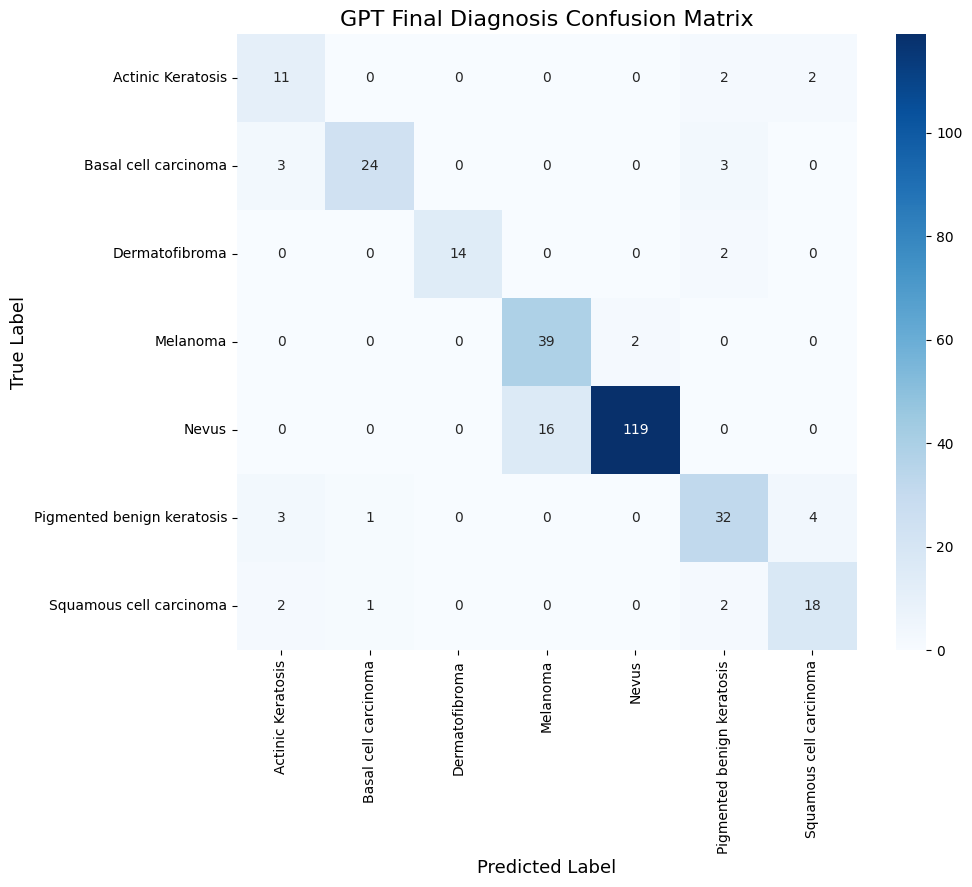

In [3]:
class_labels = sorted(list(set(y_true) | set(y_final_pred)))
plot_confusion_matrix(y_true, y_final_pred, class_labels=class_labels, title='GPT Final Diagnosis Confusion Matrix')

In [4]:
# Rationale-based metrics (using aligned cases)
# We need the original case objects for these metrics
aligned_image_paths = set(df_aligned["image_path"])
all_cases = read_jsonl_file("../results/final-gpt.jsonl")
aligned_cases = [c for c in all_cases if Path(c.get("image_path", "")).stem in aligned_image_paths]

grounded_cnt = 0
unsupported_cnt = 0
total_claims = 0
citations = []
contradictions = []

for c in aligned_cases:
    # Grounded & unsupported
    g, u, t = grounded_and_unsupported_counts(c, lexicon=DEFAULT_LEXICON)
    grounded_cnt += g
    unsupported_cnt += u
    total_claims += t

    # Citation rate
    citations.append(evidence_citation_rate(c))

    # Contradictions
    contradictions.append(any(contradiction_flags(c).values()))

print("### Rationale Metrics ###")
print(f"✅ Evidence Citation Rate: {np.nanmean(citations):.4f}")
print(f"✅ Grounded-evidence Rate: {grounded_cnt/total_claims:.4f}")
print(f"✅ Unsupported-claim Rate: {unsupported_cnt/total_claims:.4f}")
print(f"✅ Contradiction Rate: {np.mean(contradictions):.4f}")

### Rationale Metrics ###
✅ Evidence Citation Rate: 1.0000
✅ Grounded-evidence Rate: 0.9323
✅ Unsupported-claim Rate: 0.0677
✅ Contradiction Rate: 0.1333
